In [16]:
import geopandas as gpd

tile = gpd.read_file("./dataset/tile_C51L41_WGS84.gpkg")
if tile.crs != "EPSG:4326":
    tile = tile.to_crs(epsg=4326)
tile_id_ = tile.iloc[0]["id"]
min_lon, min_lat, max_lon, max_lat = tile.total_bounds
center = [(min_lat + max_lat) / 2, (min_lon + max_lon) / 2]
bbox = list([ float(b) for b in tile.total_bounds ])
min_lon, min_lat, max_lon, max_lat = bbox
print(tile.crs)
print(bbox)
print(center)
print(tile_id_)

EPSG:4326
[-61.25000000000001, -8.25, -61.0, -7.999999999999998]
[np.float64(-8.125), np.float64(-61.125)]
C51L41


In [17]:
import math
from geopy.distance import geodesic

# 1. Dados de entrada
min_lon, min_lat, max_lon, max_lat = bbox

# Centro
center_lat = (min_lat + max_lat) / 2  # -8.125
center_lon = (min_lon + max_lon) / 2  # -61.125
centro = (center_lat, center_lon)

# 2. Distâncias do centro até as 4 bordas e até o canto
dist_norte = geodesic(centro, (max_lat, center_lon)).meters  # Centro -> Borda Norte
dist_leste = geodesic(centro, (center_lat, max_lon)).meters  # Centro -> Borda Leste
dist_canto = geodesic(centro, (max_lat, max_lon)).meters  # Centro -> Vértice

# 3. Escolha o valor conforme a sua necessidade:
buffer_inscrito = min(
    dist_norte, dist_leste
)  # Fica contido dentro do bbox (sem vazar)
buffer_medio = (dist_norte + dist_leste) / 2  # Média das bordas
buffer_circunscrito = dist_canto  # Cobre 100% da área do bbox (inclui cantos)

print(f"Distância Norte/Sul: {dist_norte:.2f} m")
print(f"Distância Leste/Oeste: {dist_leste:.2f} m")
print("-" * 40)
print(f"buffer_meters (Inscrito)    : {buffer_inscrito:.2f} m")
print(f"buffer_meters (Médio)       : {buffer_medio:.2f} m")
print(f"buffer_meters (Circunscrito): {buffer_circunscrito:.2f} m")

Distância Norte/Sul: 13824.52 m
Distância Leste/Oeste: 13776.18 m
----------------------------------------
buffer_meters (Inscrito)    : 13776.18 m
buffer_meters (Médio)       : 13800.35 m
buffer_meters (Circunscrito): 19518.17 m


In [ ]:
from rs_embed import OutputSpec, PointBuffer, TemporalSpec, get_embeddings_batch

my_points = [[-45.803332, -23.167152]]

embs = get_embeddings_batch(
    "tessera",                       # any of the 14 models, same interface
    spatials=[PointBuffer(lon=lo, lat=la, buffer_m=300) for lo, la in my_points],
    temporal=TemporalSpec.range("2024-01-01", "2024-12-31"),
    output=OutputSpec.grid(),
)

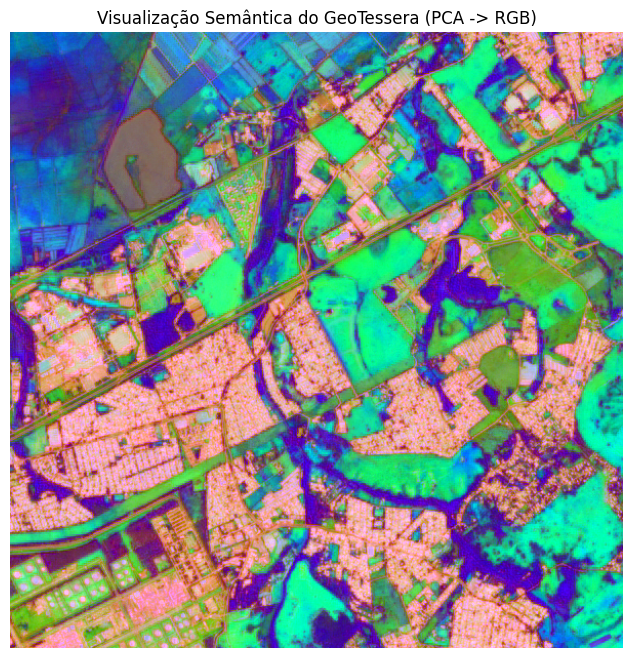

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

embedding = embs[0]

# 1. Extrair o array numpy e reordenar de (d, y, x) para (y, x, d)
# Supondo que seu objeto seja `embedding.data`
emb_array = embedding.data.values  # shape: (128, 408, 410)
emb_transposed = np.transpose(emb_array, (1, 2, 0))  # shape: (408, 410, 128)

H, W, D = emb_transposed.shape
pixels = emb_transposed.reshape(-1, D)  # shape: (408 * 410, 128)

# 2. Aplicar PCA para reduzir de 128 dimensões para 3 (RGB)
pca = PCA(n_components=3, random_state=42)
rgb_projected = pca.fit_transform(pixels)

# 3. Normalizar os valores para a escala [0, 1] com percentis (evita distorções por outliers)
p2, p98 = np.percentile(rgb_projected, (2, 98), axis=0)
rgb_normalized = np.clip((rgb_projected - p2) / (p98 - p2), 0, 1)

# 4. Remodelar de volta para a imagem 2D (H, W, 3)
rgb_image = rgb_normalized.reshape(H, W, 3)

# 5. Plotar
plt.figure(figsize=(8, 8))
plt.imshow(rgb_image)
plt.title("Visualização Semântica do GeoTessera (PCA -> RGB)")
plt.axis("off")
plt.show()